# Prophet
Questo modello sarà utilizzato come riferimento per valutare i risultati ottenuti attraverso la combinazione di BERT e reti neurali.

In [1]:
!pip install -q prophet

In [2]:
import numpy as np
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import prophet

In [3]:
df = pd.read_csv("gas_prices.csv")

In [4]:
df['Date'] = df.Date.apply(lambda x: pd.to_datetime(x[:10]))
df = df.loc[df.Date >= '2019-06-19']

In [5]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
415,2019-06-19,10.485000,10.485000,10.485000,10.485000,10.485000,0
416,2019-06-20,10.150000,10.150000,10.150000,10.150000,10.150000,0
417,2019-06-21,9.800000,10.355000,9.775000,10.355000,10.355000,70
418,2019-06-24,10.200000,10.200000,10.200000,10.200000,10.200000,5
419,2019-06-25,9.875000,9.875000,9.845000,9.845000,9.845000,10
...,...,...,...,...,...,...,...
1322,2023-01-24,66.000000,66.000000,58.269001,58.269001,58.269001,0
1323,2023-01-25,57.250000,57.250000,56.599998,56.660000,56.660000,4
1324,2023-01-26,56.599998,56.599998,54.814999,54.814999,54.814999,1
1325,2023-01-27,53.500000,55.424999,53.000000,55.424999,55.424999,6


Sono state modellate due feature binarie che indicano se l'osservazione è stata effettuata durante il periodo di crisi energetica o meno.

In [6]:
data = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

In [7]:
data['pre_crisis'] = (data['ds'] <= pd.to_datetime('2021-10-10')) 
data['post_crisis'] = ~data['pre_crisis']

In [8]:
data

,ds,y,pre_crisis,post_crisis
415,2019-06-19,10.485000,True,False
416,2019-06-20,10.150000,True,False
417,2019-06-21,10.355000,True,False
418,2019-06-24,10.200000,True,False
419,2019-06-25,9.845000,True,False
...,...,...,...,...
1322,2023-01-24,58.269001,False,True
1323,2023-01-25,56.660000,False,True
1324,2023-01-26,54.814999,False,True
1325,2023-01-27,55.424999,False,True


Il dataset è stato diviso in train e test set, usando come split la data del 1° Dicembre 2022.

In [9]:
train = data.loc[data.ds < '2022-12-01']
test = data.loc[data.ds >= '2022-12-01']

In [10]:
print(f"Training set size: {len(train)}")
print(f"Test set size: {len(test)}")

Training set size: 872
Test set size: 40


Il modello Prophet è stato creato specificando due seasonality annuali differenti, a seconda che ci si trovi durante il periodo di crisi o no.


La seasonality annuale durante la crisi ha un ordine di Fourier più alto per consentire di modellare con maggiore precisione le dinamiche oscillatorie del prezzo durante questo periodo.

Entrambe le seasonality sono state modellate con effetto moltiplicativo rispetto al trend generale.

In [11]:
periods = (np.max(test.ds) - np.max(train.ds)).days

model = prophet.Prophet(
    yearly_seasonality=False, daily_seasonality=False, 
                        weekly_seasonality=False, changepoint_prior_scale=.01,
                        changepoint_range=0.99, seasonality_mode='multiplicative'
                        )
model.add_seasonality(name='yearly_pre_crisis', period=365, fourier_order=3, 
                      prior_scale=1, condition_name='pre_crisis')
model.add_seasonality(name='yearly_post_crisis', period=365, fourier_order=5, 
                      prior_scale=1, condition_name='post_crisis')
model.fit(train)

future = model.make_future_dataframe(periods=periods)
future['pre_crisis'] = (future['ds'] <= pd.to_datetime('2021-10-10'))
future['post_crisis'] = ~future['pre_crisis']

preds = model.predict(future)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpdwnjhan4/r9fhbh9v.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdwnjhan4/8gonin9l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.8/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87637', 'data', 'file=/tmp/tmpdwnjhan4/r9fhbh9v.json', 'init=/tmp/tmpdwnjhan4/8gonin9l.json', 'output', 'file=/tmp/tmpdwnjhan4/prophet_modely1lmyggq/prophet_model-20230223120214.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:02:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:02:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


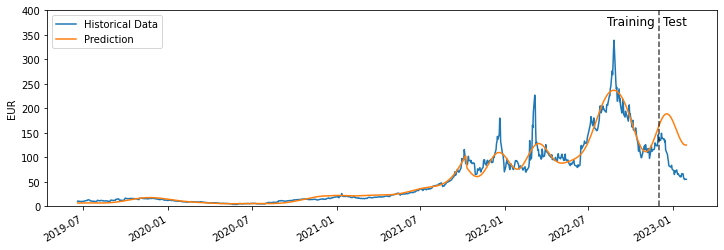

In [12]:
fig, ax = plt.subplots(1,1, figsize=(12,4))

data.plot(x='ds', y='y', ax=ax, label='Historical Data')
preds.plot(x='ds', y='yhat', ax=ax, label='Prediction')
ax.axvline(x='2022-12-01', ls='--', color='black', alpha=.7)
ax.set_ylim(0,400)
ax.text(s='Training', x='2022-08-10', y=370, fontsize='12')
ax.text(s='Test', x='2022-12-10', y=370, fontsize='12')
ax.set_xlabel(None)
ax.set_ylabel('EUR')
plt.show()

Il modello non è in grado di predire correttamente i valori del prezzo per il test set a causa del repentino cambio in discesa del trend, mai osservato prima.

In [13]:
error_train = train[['ds', 'y']].merge(preds[['ds', 'yhat']], on='ds', how='inner')
error_test = test[['ds', 'y']].merge(preds[['ds', 'yhat']], on='ds', how='inner')

In [14]:
print('Prophet prediction error:')

print('TRAIN MAE: {:.4f}'.format(mean_absolute_error(error_train.y, error_train.yhat)))
print('TRAIN RMSE: {:.4f}'.format(mean_squared_error(error_train.y, error_train.yhat, squared=False)))

print('TEST MAE: {:.4f}'.format(mean_absolute_error(error_test.y, error_test.yhat)))
print('TEST RMSE: {:.4f}'.format(mean_squared_error(error_test.y, error_test.yhat, squared=False)))

Prophet prediction error:
TRAIN MAE: 6.6376
TRAIN RMSE: 12.2430
TEST MAE: 71.4165
TEST RMSE: 74.8558


Questa ipotesi viene confermata anche dall'errore, che risulta essere accettabile per il training set e molto più alto per il test set.